In [1]:
from pathlib import Path
import joblib

BASE_DIR = Path("/Users/chanodyafernando/ML project")

preprocessor = joblib.load(BASE_DIR / "preprocessor.pkl")
X_train, X_test, y_train, y_test = joblib.load(BASE_DIR / "data_split.pkl")
label_encoder = joblib.load(BASE_DIR / "label_encoder.pkl")

X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Loaded shared preprocessing files successfully.")
print("Train shape:", X_train_processed.shape)
print("Test shape:", X_test_processed.shape)
print("Classes:", label_encoder.classes_)


Loaded shared preprocessing files successfully.
Train shape: (5285, 40)
Test shape: (1322, 40)
Classes: ['High' 'Low' 'Medium']


In [2]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

param_grid = [
    {
        "kernel": ["linear"],
        "C": [0.1, 1, 10]
    },
    {
        "kernel": ["rbf"],
        "C": [0.1, 1, 10],
        "gamma": ["scale", 0.01, 0.1, 1]
    }
]

grid_search = GridSearchCV(
    estimator=SVC(),
    param_grid=param_grid,
    scoring="accuracy",
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_processed, y_train)


best_svm_model = grid_search.best_estimator_

print("Best parameters:", grid_search.best_params_)
print("Best cross-validation accuracy:", round(grid_search.best_score_, 4))


Fitting 5 folds for each of 15 candidates, totalling 75 fits
Best parameters: {'C': 1, 'kernel': 'linear'}
Best cross-validation accuracy: 0.9485


In [3]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import pandas as pd

y_pred = best_svm_model.predict(X_test_processed)

svm_metrics = {
    "Model": "SVM",
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred, average="weighted", zero_division=0),
    "Recall": recall_score(y_test, y_pred, average="weighted", zero_division=0),
    "F1-Score": f1_score(y_test, y_pred, average="weighted", zero_division=0)
}

pd.DataFrame([svm_metrics])


,Model,Accuracy,Precision,Recall,F1-Score
0,SVM,0.937216,0.936973,0.937216,0.936958


In [4]:
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_, zero_division=0))


              precision    recall  f1-score   support

        High       0.95      0.97      0.96       441
         Low       0.94      0.95      0.95       441
      Medium       0.92      0.89      0.91       440

    accuracy                           0.94      1322
   macro avg       0.94      0.94      0.94      1322
weighted avg       0.94      0.94      0.94      1322



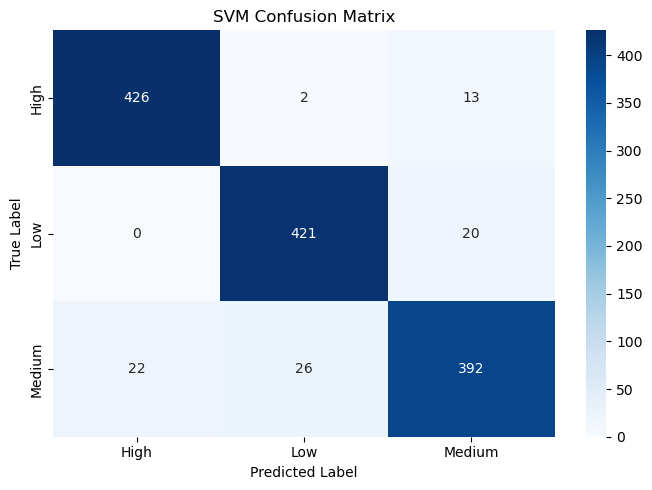

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()
